## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

In [65]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Import Dataset

In [2]:
path_to_easyvisa_data = Path('data', 'EasyVisa.csv')

#### Using pathlib to specify path to the dataset.

In [3]:
df_easyvisa = pd.read_csv(path_to_easyvisa_data)

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [4]:
df_easyvisa.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### Understand the shape of the dataset

In [5]:
print(f'Shape of the Easy Visa dataframe is: {df_easyvisa.shape}')

Shape of the Easy Visa dataframe is: (25480, 12)


#### Check the data types of the columns for the dataset

In [6]:
df_easyvisa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [7]:
df_easyvisa.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [8]:
for column_name in df_easyvisa.columns:
    print('###################################')
    print(f'Value counts or freqencies for {column_name}')
    print(df_easyvisa[column_name].value_counts())
    print('###################################')

###################################
Value counts or freqencies for case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV12       1
EZYV13       1
EZYV14       1
EZYV15       1
EZYV16       1
Name: count, Length: 25480, dtype: int64
###################################
###################################
Value counts or freqencies for continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
###################################
###################################
Value counts or freqencies for education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
###################################
###################################
Value counts or freqencies for has_job_experience
has_job_experience
Y    14802
N    10678
Name

In [9]:
df_easyvisa.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


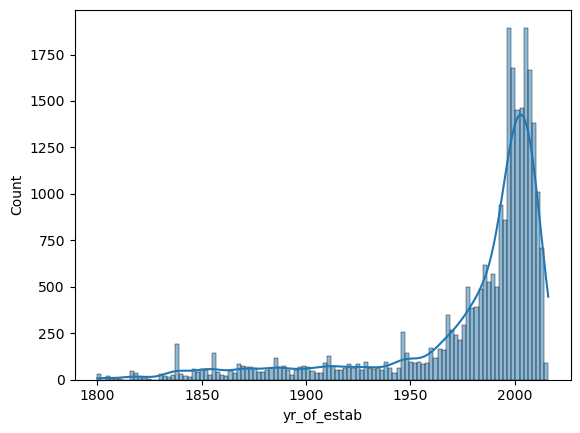

In [10]:
sns.histplot(data=df_easyvisa, x="yr_of_estab", kde=True);

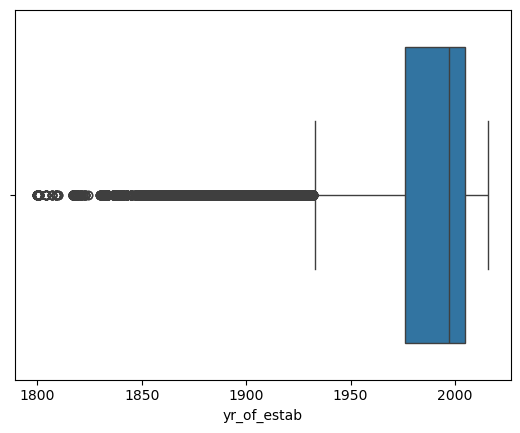

In [11]:
sns.boxplot(data=df_easyvisa, x="yr_of_estab");

* Feature Engineering for year of establishment

#### Categorize company by year of establishment

* Before 1975: Legacy Company(L)
* 1975 and before 2000: Stable Company (S)
* 2000 and later: New Company (N)

In [39]:
def company_age(x):
    if x<=1975:
        company_age_flag = 'L'
    elif ((x>=1975) and (x<2000)):
        company_age_flag = 'S'
    else:
        company_age_flag = 'N'
        
    return company_age_flag

In [40]:
df_easyvisa['business_age'] = df_easyvisa['yr_of_estab'].apply(company_age)

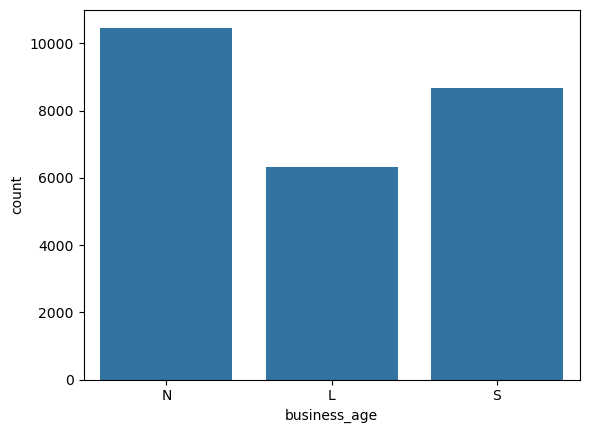

In [41]:
sns.countplot(df_easyvisa, x="business_age");

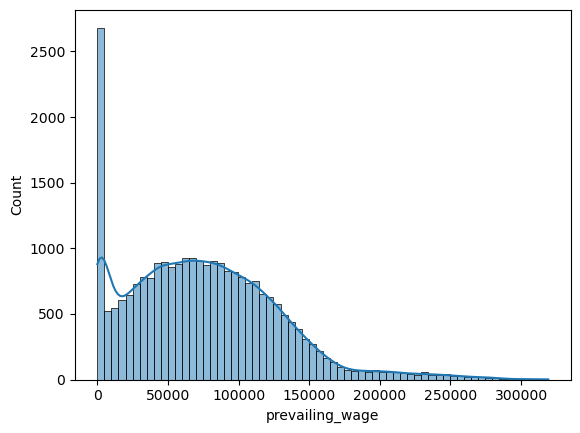

In [12]:
sns.histplot(data=df_easyvisa, x="prevailing_wage", kde=True);

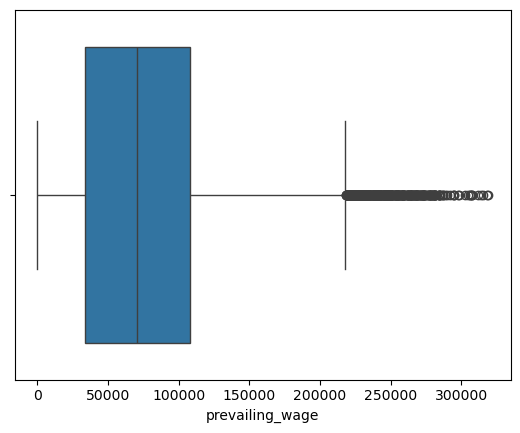

In [13]:
sns.boxplot(data=df_easyvisa, x="prevailing_wage");

#### Fixing the negative values in number of employees columns

In [14]:
df_easyvisa[df_easyvisa["no_of_employees"]<=0]["no_of_employees"]

245     -25
378     -11
832     -17
2918    -26
6439    -14
6634    -26
7224    -25
7281    -14
7318    -26
7761    -11
9872    -26
11493   -14
13471   -17
14022   -11
14146   -26
14726   -11
15600   -14
15859   -11
16157   -11
16883   -26
17006   -11
17655   -17
17844   -14
17983   -26
20815   -17
20984   -14
21255   -25
21760   -25
21944   -25
22084   -14
22388   -14
23186   -11
23476   -11
Name: no_of_employees, dtype: int64

In [15]:
df_easyvisa["no_of_employees"]=np.abs(df_easyvisa["no_of_employees"])
df_easyvisa[df_easyvisa["no_of_employees"]<=0]["no_of_employees"]

Series([], Name: no_of_employees, dtype: int64)

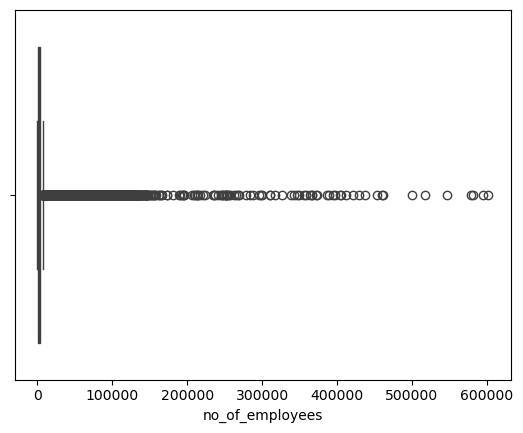

In [16]:
# right skewed distribution
sns.boxplot(data=df_easyvisa, x="no_of_employees");

* Feature Engineering for number of employees

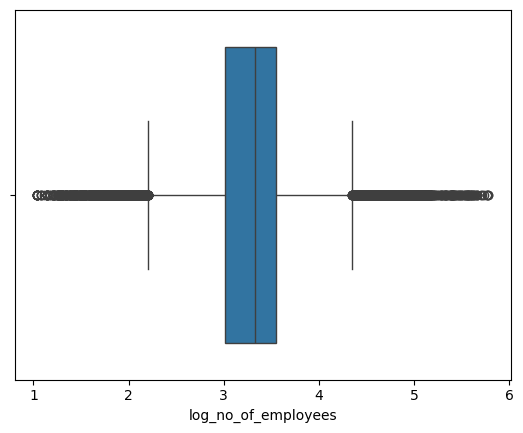

In [17]:
df_easyvisa["log_no_of_employees"]=np.log10(df_easyvisa["no_of_employees"])
sns.boxplot(data=df_easyvisa, x="log_no_of_employees");

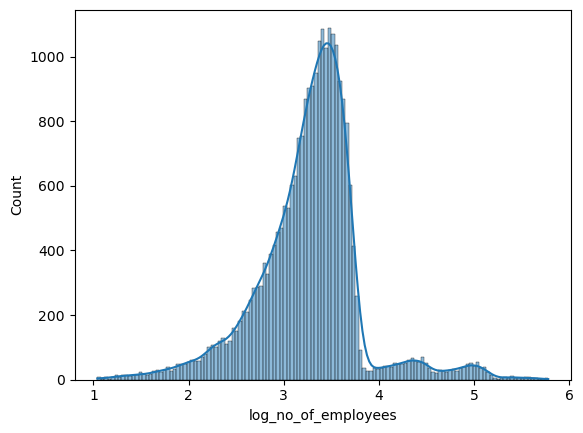

In [18]:
sns.histplot(data=df_easyvisa, x="log_no_of_employees", kde=True);

#### Categorize number of employees

* Less than or equal to 1,000 employees: Small Business (S)
* Greater than 1,000 and less than or equal to 10,000 employees: Medium Business (M)
* Greather than 10,000 employees: Large Business (L)

In [19]:
def business_size(x):
    if x<=1000:
        business_flag = 'S'
    elif ((x>=1000) and (x<10000)):
        business_flag = 'M'
    else:
        business_flag = 'L'
        
    return business_flag

In [20]:
df_easyvisa['business_size'] = df_easyvisa['no_of_employees'].apply(business_size)

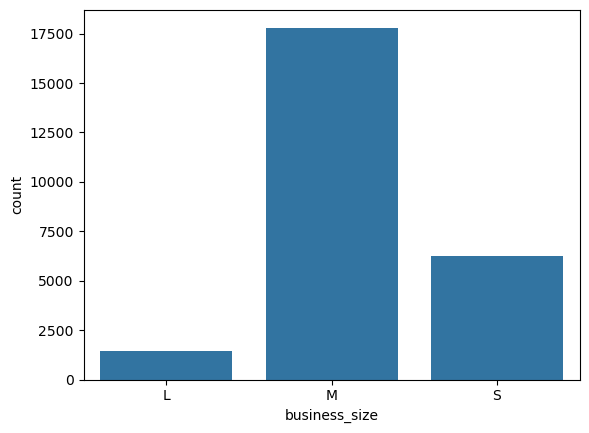

In [21]:
sns.countplot(df_easyvisa, x="business_size");

#### Let's check the count of each unique category in each of the categorical variables

In [22]:
df_easyvisa.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status', 'log_no_of_employees',
       'business_size'],
      dtype='object')

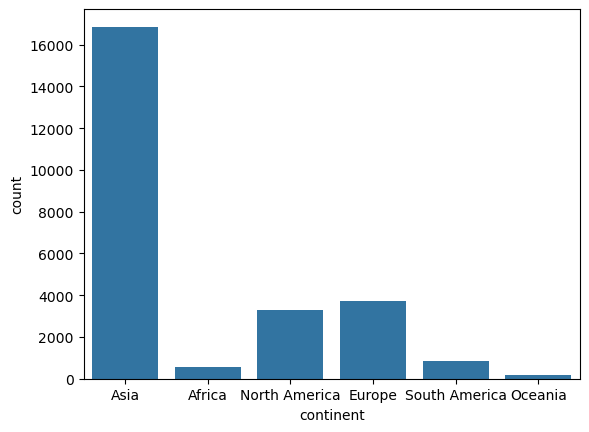

In [23]:
sns.countplot(df_easyvisa, x="continent");

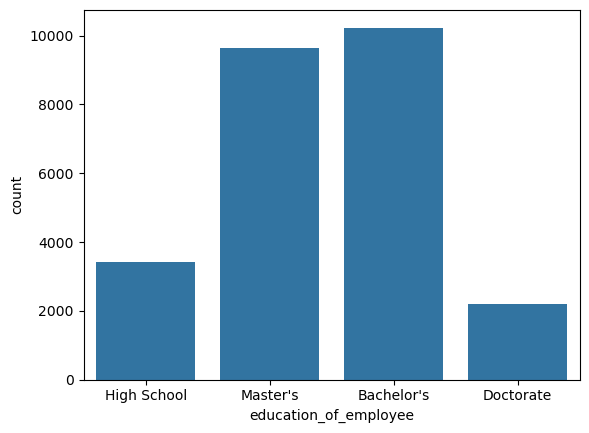

In [24]:
sns.countplot(df_easyvisa, x="education_of_employee");

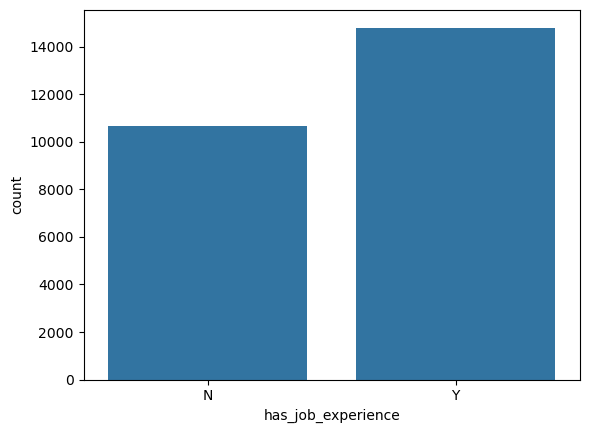

In [25]:
sns.countplot(df_easyvisa, x="has_job_experience");

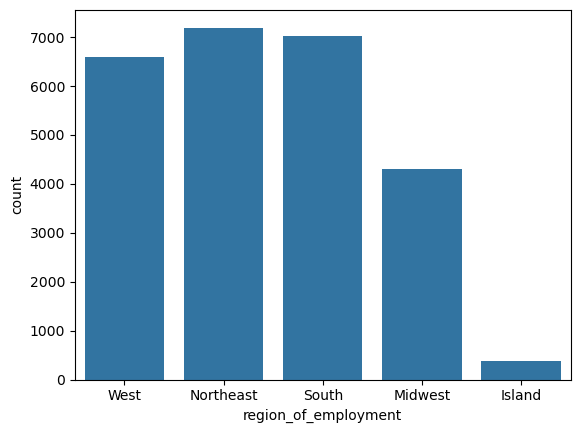

In [26]:
sns.countplot(df_easyvisa, x="region_of_employment");

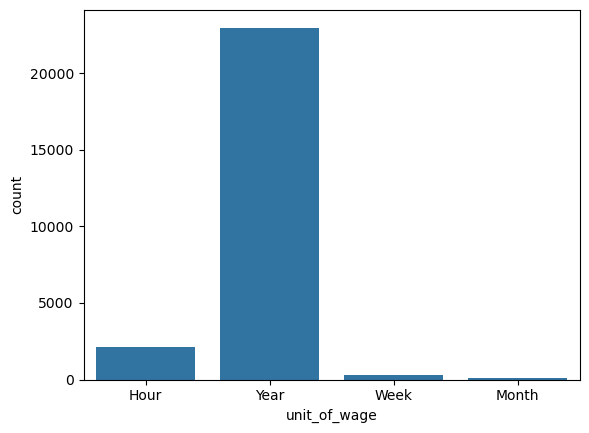

In [27]:
sns.countplot(df_easyvisa, x="unit_of_wage");

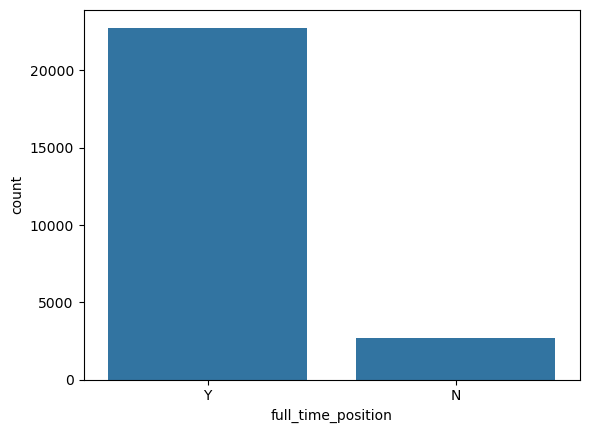

In [28]:
sns.countplot(df_easyvisa, x="full_time_position");

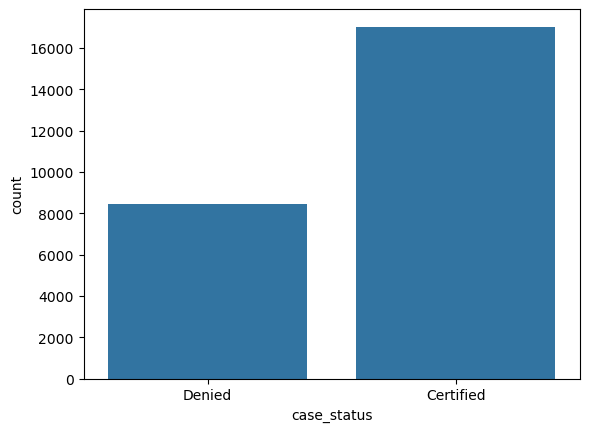

In [29]:
sns.countplot(df_easyvisa, x="case_status");

In [30]:
df_easyvisa["case_status"].value_counts(normalize=True)

case_status
Certified    0.667896
Denied       0.332104
Name: proportion, dtype: float64

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

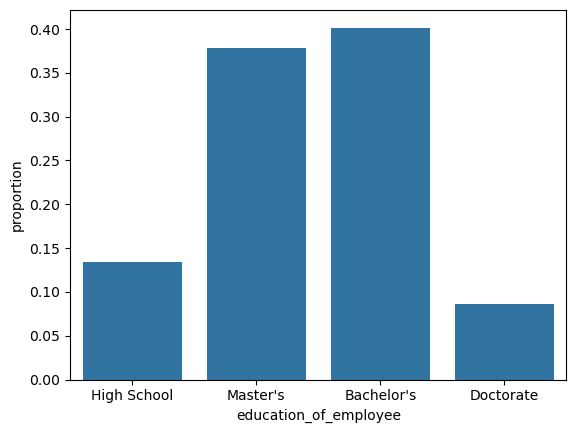

In [56]:
sns.countplot(df_easyvisa, x="education_of_employee", stat="proportion");

* More than 85% of applicants have Bachelor's or higher education levels
* Most common education level is Bachelor's followed by Master's, with the least common being Doctorate.

#### Observations on region of employment

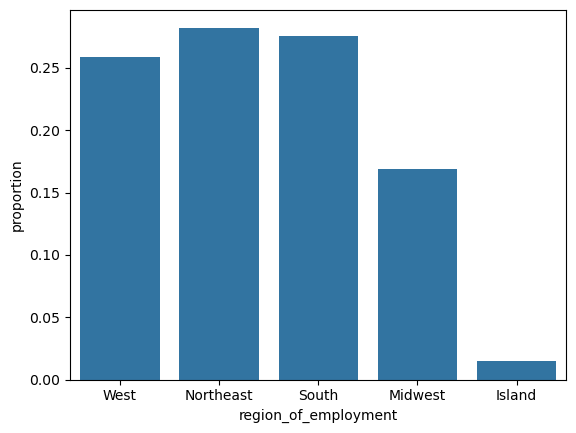

In [57]:
sns.countplot(df_easyvisa, x="region_of_employment", stat="proportion");

* More than 75% of applicants are from West, Northeast, and South regions
* Most common region is Northeast followed by South and West. Least common is Island. These seem to follow population centers.

#### Observations on job experience

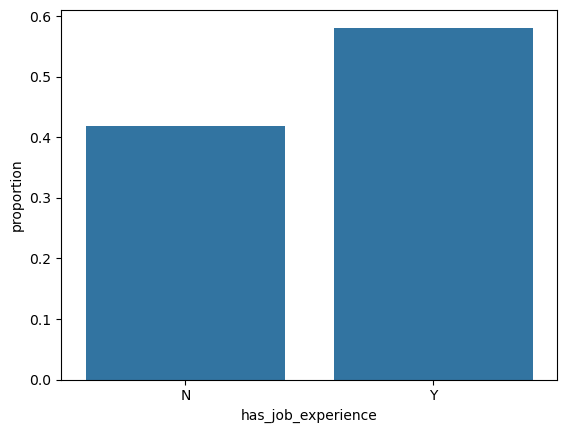

In [58]:
sns.countplot(df_easyvisa, x="has_job_experience", stat="proportion");

* Close to 60% of all the applicants have job experience and a little more than 40% of applicants do not have any job experience.

#### Observations on case status

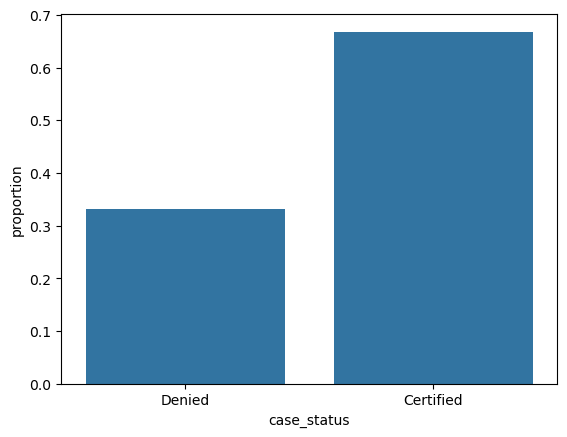

In [59]:
sns.countplot(df_easyvisa, x="case_status", stat="proportion");

* The target signal is imbalanced or the number of cases denied is around 1/3 and number of cases approve is 2/3.
* This dataset is *relatively* better balanced than the example cases in the course where we saw 1/10 to 9/10 imbalances in our target dataset.
* Will be interesting to see how upsampling the 'Denied' case status or downsampling 'Certified' case status affects model performance.

### Bivariate Analysis

**Creating functions that will help us with further analysis.**

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
sns.pairplot(df_easyvisa, hue='case_status');

In [31]:
df_easyvisa.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status', 'log_no_of_employees',
       'business_size'],
      dtype='object')

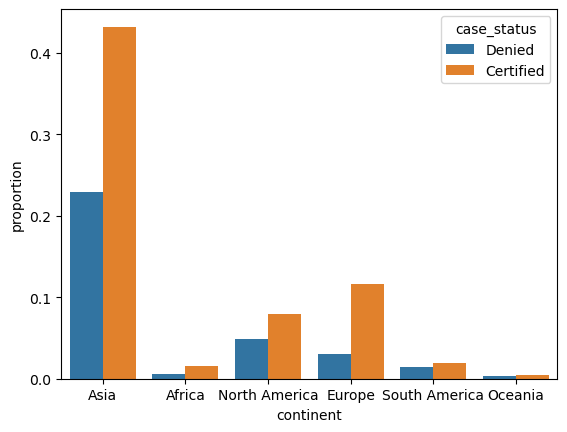

In [32]:
sns.countplot(df_easyvisa, x='continent', hue='case_status', stat='proportion');

In [49]:
df_easyvisa[['continent', 'case_status']].groupby('continent').value_counts(normalize=True)

continent      case_status
Africa         Certified      0.720508
               Denied         0.279492
Asia           Certified      0.653105
               Denied         0.346895
Europe         Certified      0.792337
               Denied         0.207663
North America  Certified      0.618773
               Denied         0.381227
Oceania        Certified      0.635417
               Denied         0.364583
South America  Certified      0.578638
               Denied         0.421362
Name: proportion, dtype: float64

* There are trends to be seen here as South America has the lowest proportion of Certified cases and Europe has highest proportion of Certified cases out of all applicants
* This would be a good feature for the baseline models

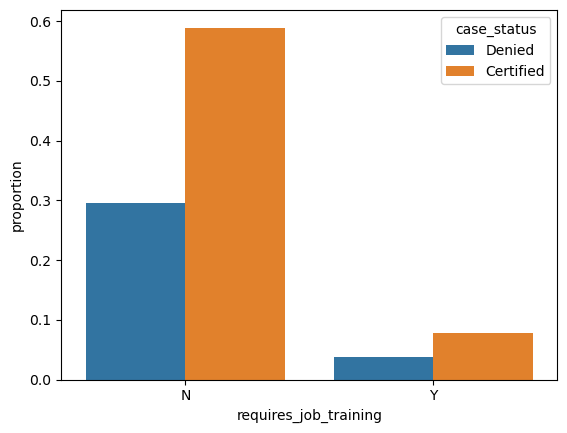

In [35]:
sns.countplot(df_easyvisa, x='requires_job_training', hue='case_status', stat='proportion');

In [52]:
df_easyvisa[['requires_job_training', 'case_status']].groupby('requires_job_training').value_counts(normalize=True)

requires_job_training  case_status
N                      Certified      0.666459
                       Denied         0.333541
Y                      Certified      0.678849
                       Denied         0.321151
Name: proportion, dtype: float64

* Not much difference in Certified proportion of cases if the applicant requires or not requires job training
* This feature might be good to be dropped

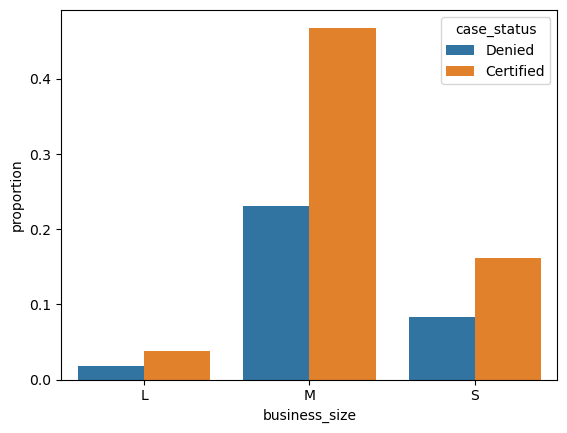

In [38]:
sns.countplot(df_easyvisa, x='business_size', hue='case_status', stat='proportion');

In [54]:
df_easyvisa[['business_size', 'case_status']].groupby('business_size').value_counts(normalize=True)

business_size  case_status
L              Certified      0.684540
               Denied         0.315460
M              Certified      0.669943
               Denied         0.330057
S              Certified      0.658228
               Denied         0.341772
Name: proportion, dtype: float64

* Not much difference in Certified proportion of cases based on business size
* This feature might be good to be dropped

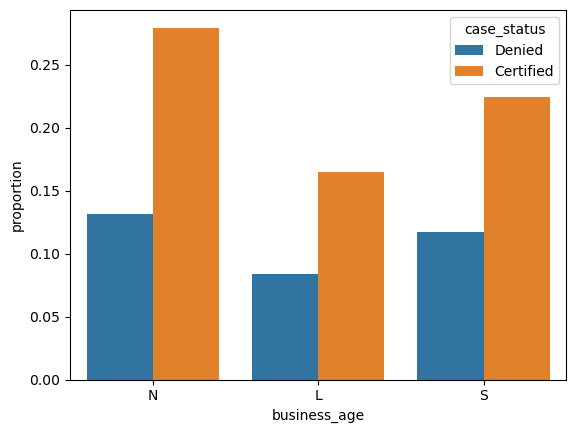

In [42]:
sns.countplot(df_easyvisa, x='business_age', hue='case_status', stat='proportion');

In [55]:
df_easyvisa[['business_age', 'case_status']].groupby('business_age').value_counts(normalize=True)

business_age  case_status
L             Certified      0.663452
              Denied         0.336548
N             Certified      0.679817
              Denied         0.320183
S             Certified      0.656765
              Denied         0.343235
Name: proportion, dtype: float64

* Not much difference in Certified proportion of cases based on business age
* This feature might be good to be dropped

* Unit of Wage is showing a clear delineation with 34% of applicants with Hourly wage unit certified relative to 70% of applicants Certified with Yearly wage unit
* This feature might be one of the prominent features for our base estimators

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

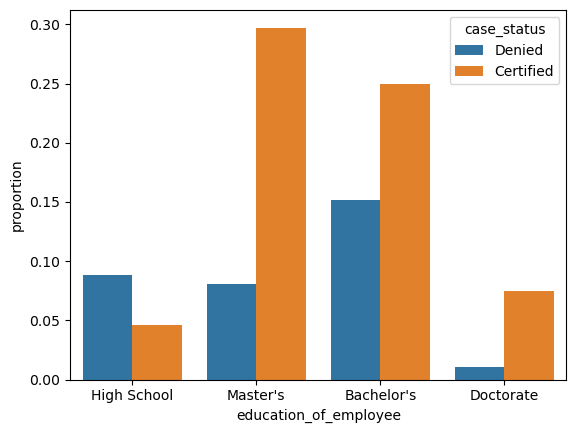

In [33]:
sns.countplot(df_easyvisa, x='education_of_employee', hue='case_status', stat='proportion');

In [50]:
df_easyvisa[['education_of_employee', 'case_status']].groupby('education_of_employee').value_counts(normalize=True)

education_of_employee  case_status
Bachelor's             Certified      0.622142
                       Denied         0.377858
Doctorate              Certified      0.872263
                       Denied         0.127737
High School            Denied         0.659649
                       Certified      0.340351
Master's               Certified      0.786278
                       Denied         0.213722
Name: proportion, dtype: float64

* High School educated folks have the highest Denied proportion and Doctorate level of educated folks have the highest Certified case_status proportion of value_counts
* The Certified case status rates are 34%, 62%, 66%, and 87% for High School, Bachelor's, Masters, and Doctorate education levels, respectively.
* This looks like an important feature for the base estimators 

#### How does visa status vary across different continents?

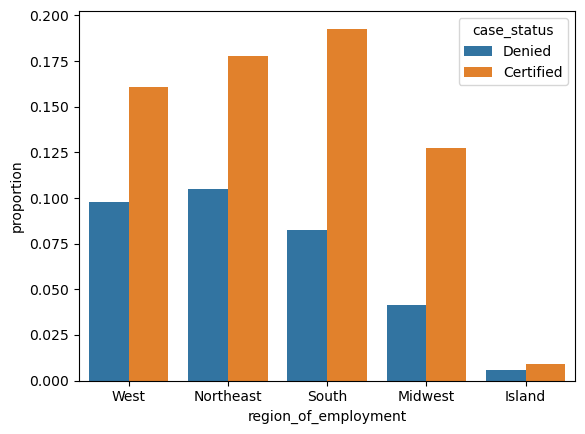

In [36]:
sns.countplot(df_easyvisa, x='region_of_employment', hue='case_status', stat='proportion');

In [53]:
df_easyvisa[['region_of_employment', 'case_status']].groupby('region_of_employment').value_counts(normalize=True)

region_of_employment  case_status
Island                Certified      0.602667
                      Denied         0.397333
Midwest               Certified      0.755282
                      Denied         0.244718
Northeast             Certified      0.629048
                      Denied         0.370952
South                 Certified      0.700157
                      Denied         0.299843
West                  Certified      0.622533
                      Denied         0.377467
Name: proportion, dtype: float64

* Region of Employment has lowest Certified proportion of 60% for Island and highest Certified proportion for Midwest at 76%
* This feature will contribute to the base estimators, but maybe not as dominant as some of the features above

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

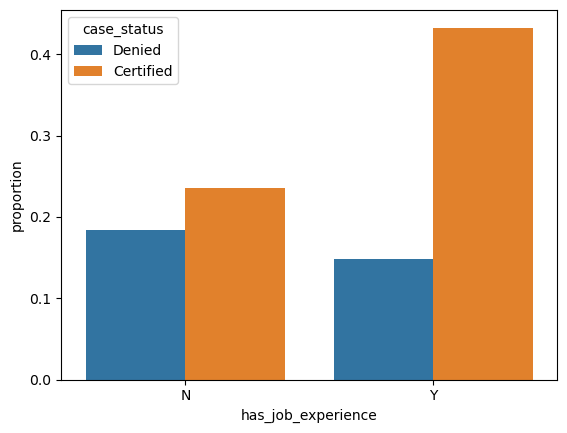

In [34]:
sns.countplot(df_easyvisa, x='has_job_experience', hue='case_status', stat='proportion');

In [51]:
df_easyvisa[['has_job_experience', 'case_status']].groupby('has_job_experience').value_counts(normalize=True)

has_job_experience  case_status
N                   Certified      0.561341
                    Denied         0.438659
Y                   Certified      0.744764
                    Denied         0.255236
Name: proportion, dtype: float64

* Job Experience has a large effect on Certified case status, with those who have prior job experience 74% of their cases are Certified relative to no prior job experience where only 56% of cases are Certified.
* This looks like an important feature for the base estimators 

#### Is the prevailing wage consistent across all regions of the US?

* Splitting up the analysis for each type of unit of wage

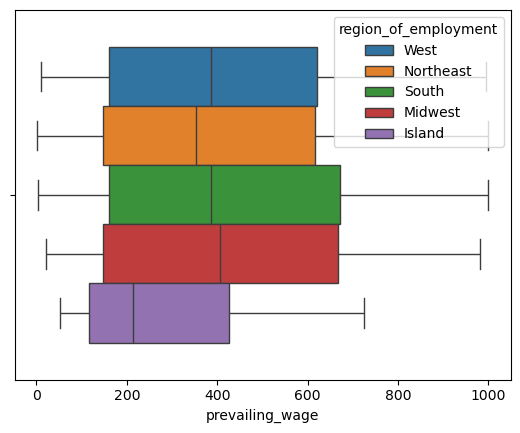

In [72]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Hour'][['region_of_employment', 'prevailing_wage']], x='prevailing_wage', hue='region_of_employment');

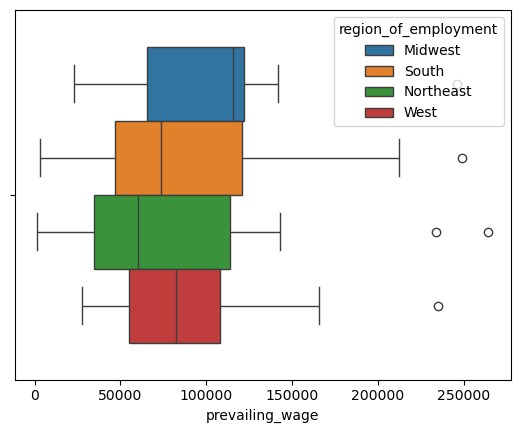

In [73]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Month'][['region_of_employment', 'prevailing_wage']], x='prevailing_wage', hue='region_of_employment');

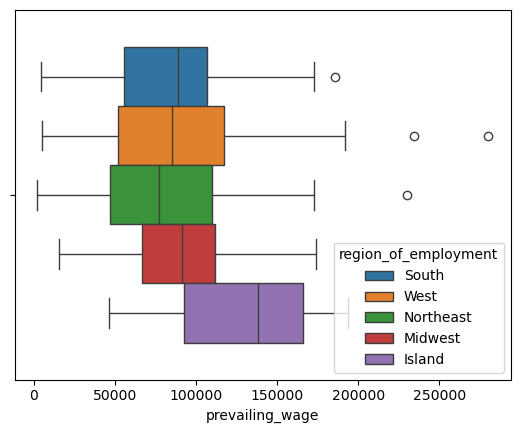

In [74]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Week'][['region_of_employment', 'prevailing_wage']], x='prevailing_wage', hue='region_of_employment');

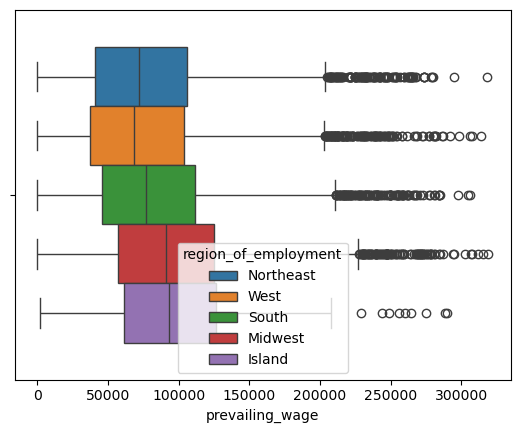

In [75]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Year'][['region_of_employment', 'prevailing_wage']], x='prevailing_wage', hue='region_of_employment');

* Weekly wage on Island is higher relatively than other regions
* For Hourly wage Island 75 percentile is close to the median of the other regions
* Other than these two findings which are less than 1% of overall data points they are almost similar
* We notice that the type of wage looks to be correlated than the value of it with our target case_status signal

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

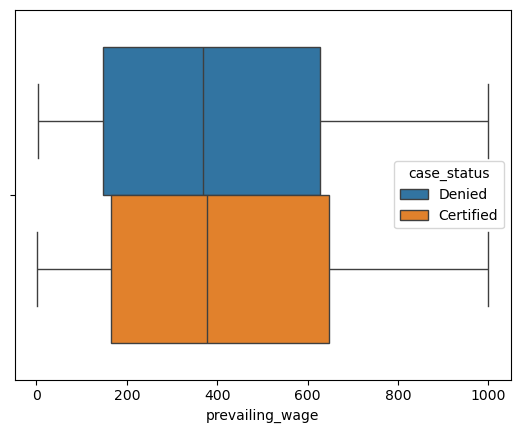

In [76]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Hour'][['case_status', 'prevailing_wage']], x='prevailing_wage', hue='case_status');

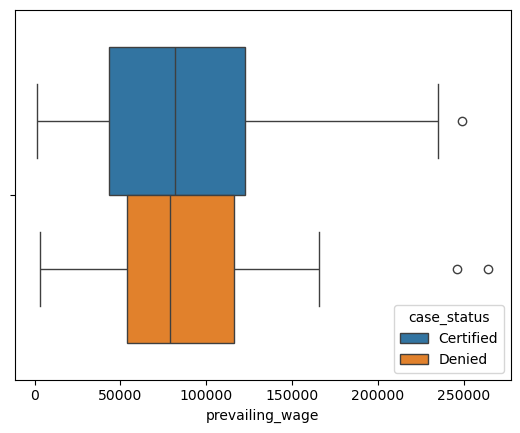

In [77]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Month'][['case_status', 'prevailing_wage']], x='prevailing_wage', hue='case_status');

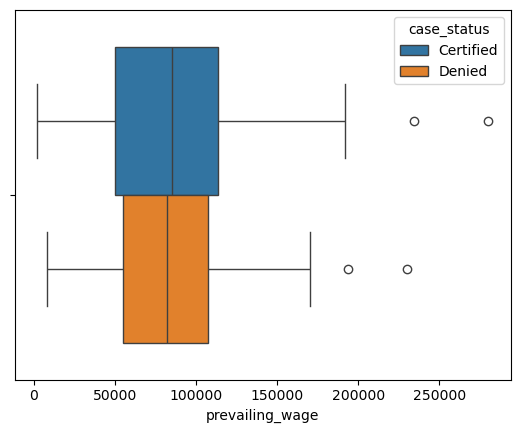

In [79]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Week'][['case_status', 'prevailing_wage']], x='prevailing_wage', hue='case_status');

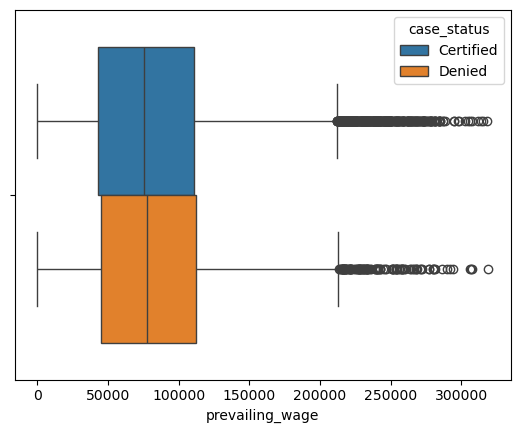

In [80]:
sns.boxplot(df_easyvisa[df_easyvisa['unit_of_wage']=='Year'][['case_status', 'prevailing_wage']], x='prevailing_wage', hue='case_status');

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

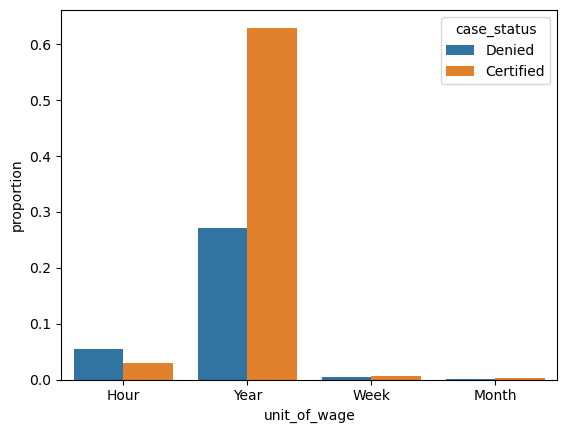

In [37]:
sns.countplot(df_easyvisa, x='unit_of_wage', hue='case_status', stat='proportion');

In [62]:
df_easyvisa[['unit_of_wage', 'case_status']].groupby('unit_of_wage').value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

## Data Pre-processing

### Outlier Check

### Data Preparation for modeling

## Model Building

### Model Evaluation Criterion

- The primary metric should be Recall or reducing False Negatives
- Since we are assisting in case approval or denial, reducing denying an application which should have been approved is critical as we have a human layer to evaluate the edge cases in greater detail. This human layer or additional layer can look into the False Positive cases and eliminate them.
- Since evaluating metrics is not time consuming we can specify Recall and F-1 score, the end user can request a switch in the model metric if they are not happy with the results of one metric over the other in actual implementation. As a developer we will be ready with an alternative model based on feedback received from our end user.

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

### Model Building with Oversampled data

### Model Building with Undersampled data

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

## Model Performance Summary and Final Model Selection

## Actionable Insights and Recommendations

<font size=6 color='blue'>Power Ahead</font>
___